## Qiskit -- Problem Set 6. QFT & QPE
Cristobal Lillo

In [25]:
import qiskit
from qiskit import *
import qiskit_ibm_runtime
import qiskit_aer

In [26]:
from math import pi

In [27]:
q = QuantumRegister(3)
c = ClassicalRegister(3)
qft = QuantumCircuit(q, c)


qft.swap(q[0], q[2])

qft.barrier()

qft.h(q[0])

# V^2_01

qft.cp(pi/2, q[0], q[1])

# V^3_02
qft.cp(pi/4, q[0], q[2])

qft.barrier()

qft.h(q[1])



qft.cp(pi/2, q[1], q[2])

qft.barrier()

qft.h(q[2])




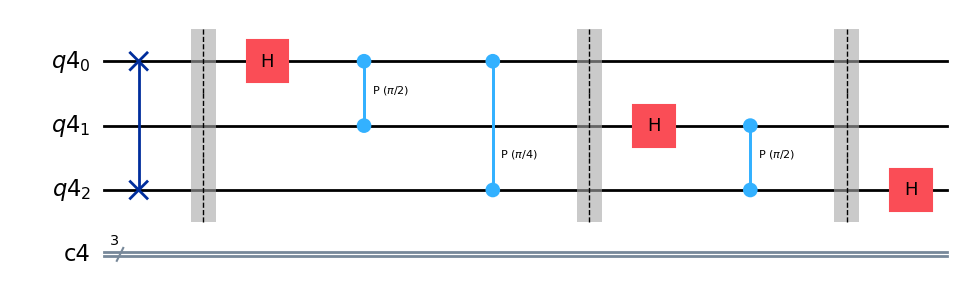

In [28]:
qft.draw(output='mpl')

In [29]:
from qiskit.quantum_info import Statevector
from pprint import pprint

sv = Statevector.from_label("101")
sv_ft = sv.evolve(qft)

pprint(sv_ft.data)

array([ 3.53553391e-01+0.j        , -2.50000000e-01-0.25j      ,
        2.16489014e-17+0.35355339j,  2.50000000e-01-0.25j      ,
       -3.53553391e-01+0.j        ,  2.50000000e-01+0.25j      ,
       -2.16489014e-17-0.35355339j, -2.50000000e-01+0.25j      ])




.353 + 0i

-.25 - 0.25i

0 + 0.353i, 

.25 - 0.25i

-.353 + 0i

.25 + 0.25i

0 - 0.353i

-.25+0.25i


### Whilst mathematica's FT yielded 

{

0.353553 + 0. i,

-0.25 - 0.25 I, 

0 + 0.353553 I,

0.25 - 0.25 I, 

-0.353553 + 0. I, 

0.25 + 0.25 I, 

0 - 0.353553 I, 

-0.25 + 0.25 I

}


 Seems to match.

In [30]:
import numpy as np
math_sv = np.array([
    0.353553 + 0.0j,
    -0.25    - 0.25j,
    0.0      + 0.353553j,
    0.25     - 0.25j,
    -0.353553 + 0.0j,
    0.25     + 0.25j,
    0.0      - 0.353553j,
    -0.25    + 0.25j
], dtype=np.complex128)

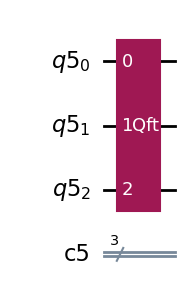

In [31]:
from qiskit.circuit.library import QFTGate

q = QuantumRegister(3)
c = ClassicalRegister(3)
qft2 = QuantumCircuit(q, c)

qft2.append(QFTGate(3), q)

qft2.draw(output='mpl')




In [32]:
sv2 = Statevector.from_label("101")  
sv_ft2 = sv2.evolve(qft2)
print(sv_ft2.data)

[ 3.53553391e-01+0.00000000e+00j -2.50000000e-01-2.50000000e-01j
  1.08244507e-16+3.53553391e-01j  2.50000000e-01-2.50000000e-01j
 -3.53553391e-01+2.16489014e-16j  2.50000000e-01+2.50000000e-01j
 -9.52770505e-16-3.53553391e-01j -2.50000000e-01+2.50000000e-01j]


[ 3.53553391e-01+0.j         -2.50000000e-01-0.25j
  2.16489014e-17+0.35355339j  2.50000000e-01-0.25j
 -3.53553391e-01+0.j          2.50000000e-01+0.25j
 -2.16489014e-17-0.35355339j -2.50000000e-01+0.25j      ]


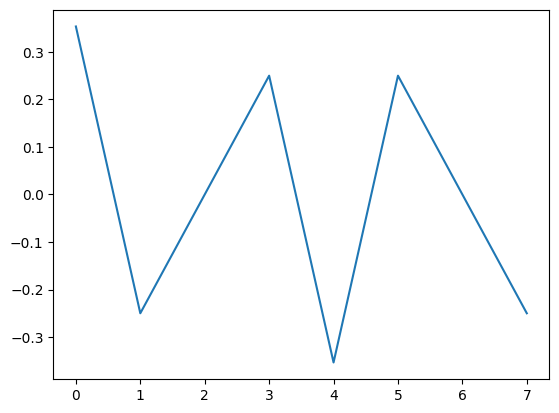

In [33]:
from matplotlib import pyplot as plt

print(sv_ft.data)
plt.plot(sv_ft.data)

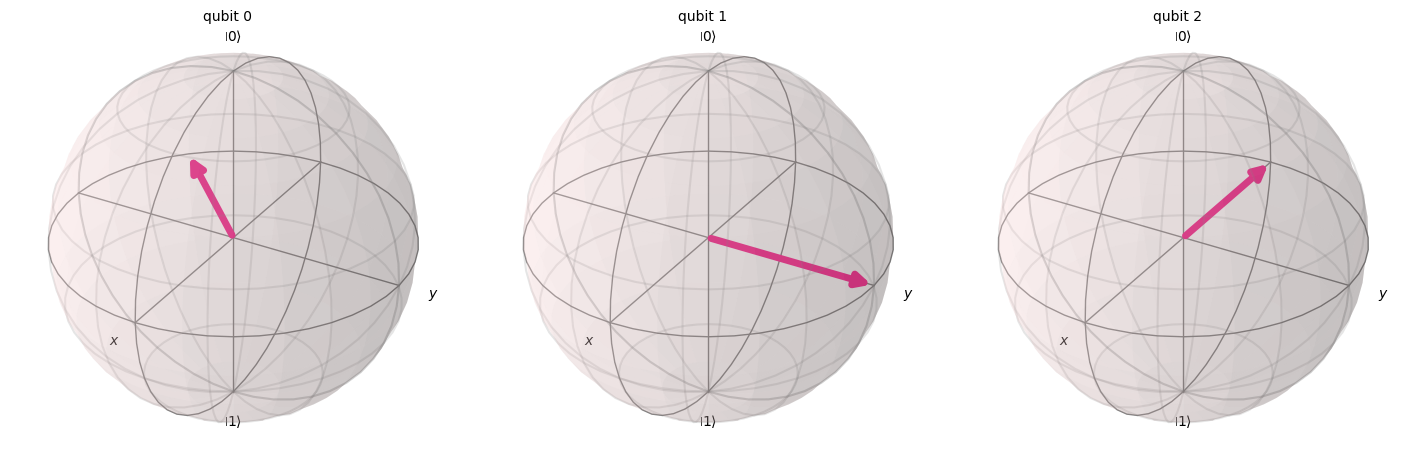

In [34]:

from qiskit.visualization import plot_bloch_multivector

plot_bloch_multivector(sv_ft)


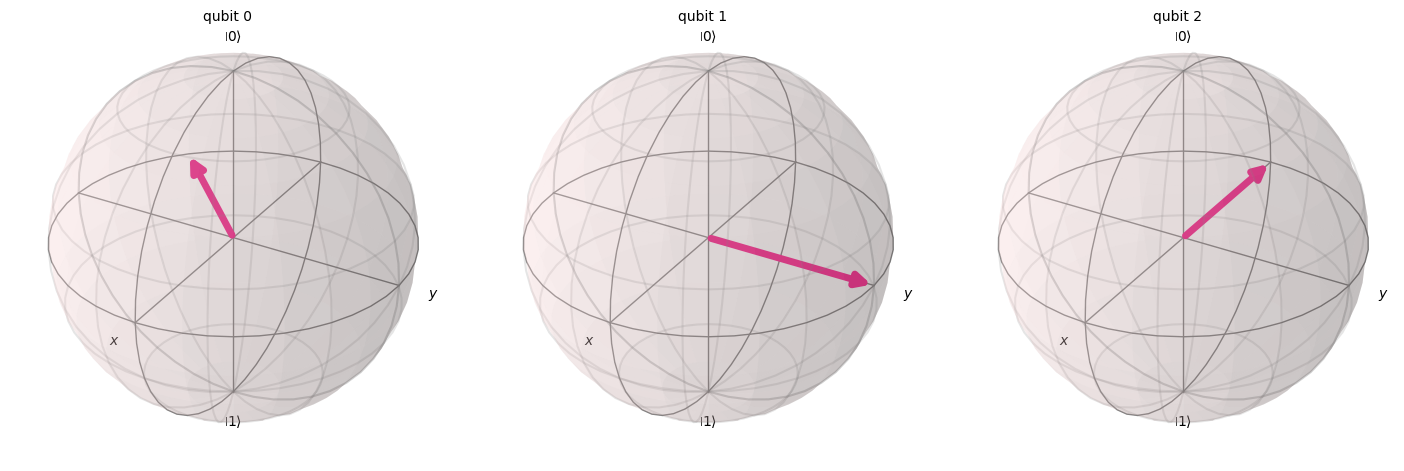

In [35]:
plot_bloch_multivector(sv_ft2)


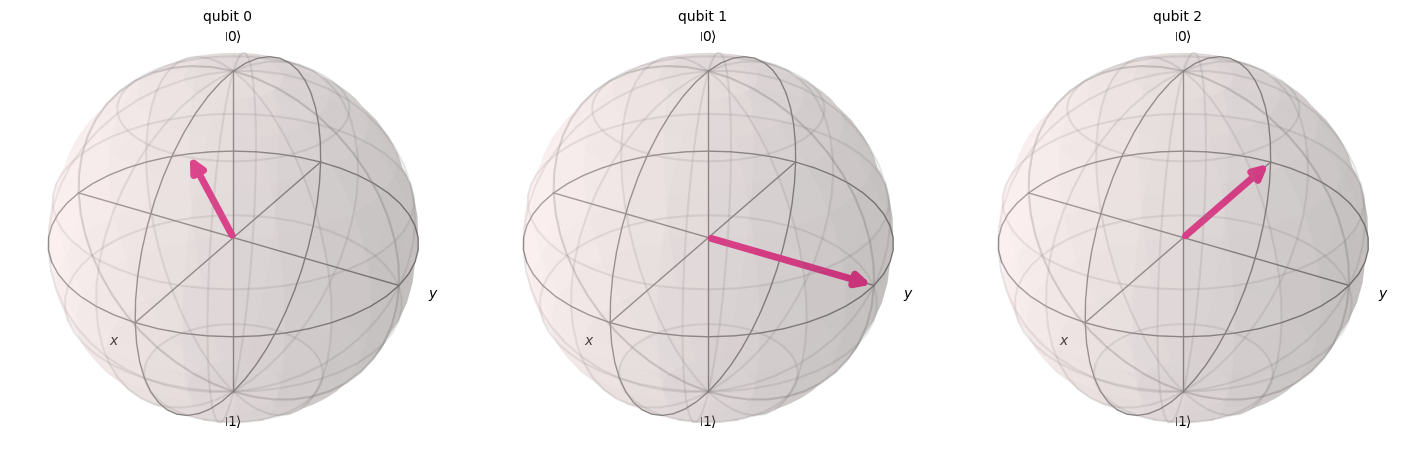

In [36]:
plot_bloch_multivector(math_sv)

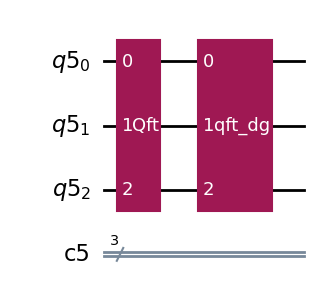

In [37]:

# inverse
qft3 = qft2.copy()
qft3.append(QFTGate(3).inverse(), q)

qft3.draw(output='mpl')

[-2.56951666e-16+1.59807152e-16j  5.55111512e-17-1.22339303e-16j
  2.43073879e-16+1.45929364e-16j -3.88578059e-16+2.83276945e-16j
 -3.40218393e-16-6.72630190e-18j  1.00000000e+00-7.50376287e-16j
  3.54096181e-16+7.15148591e-18j  3.88578059e-16+2.83276945e-16j]


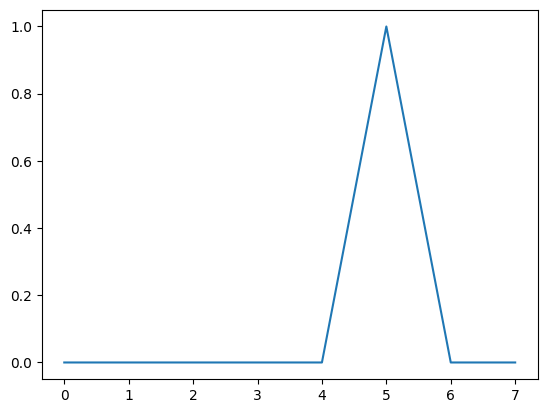

In [38]:
sv3 = Statevector.from_label("101")  
sv_ft3 = sv3.evolve(qft3) # should return 101
print(sv_ft3.data)

import matplotlib.pyplot as plt
plt.plot(sv_ft3.data)

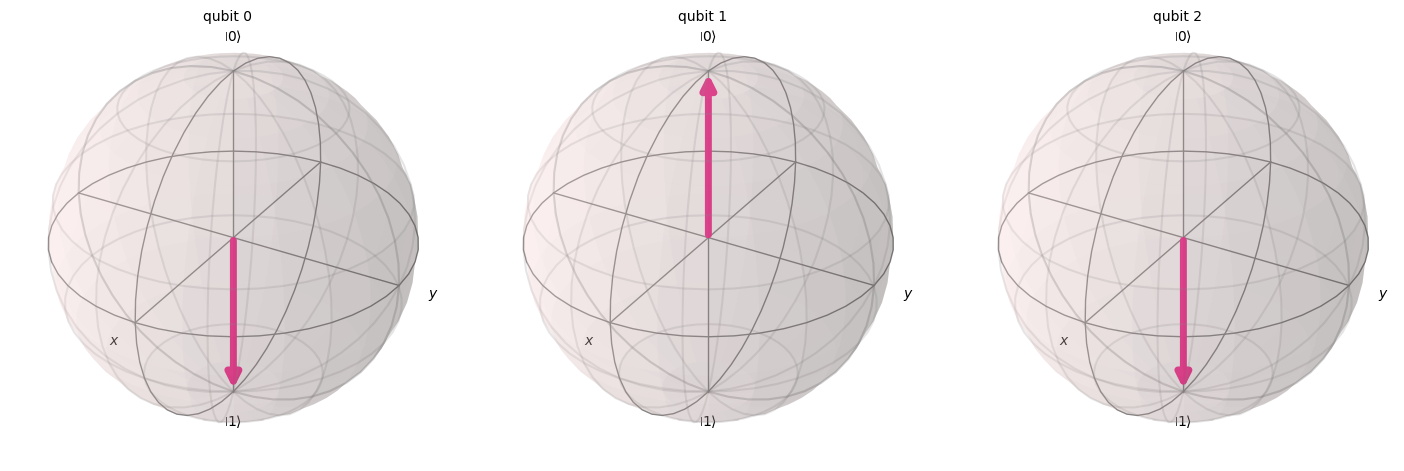

In [39]:
plot_bloch_multivector(sv_ft3)

> it is indeed in the state $|5\rangle_3$

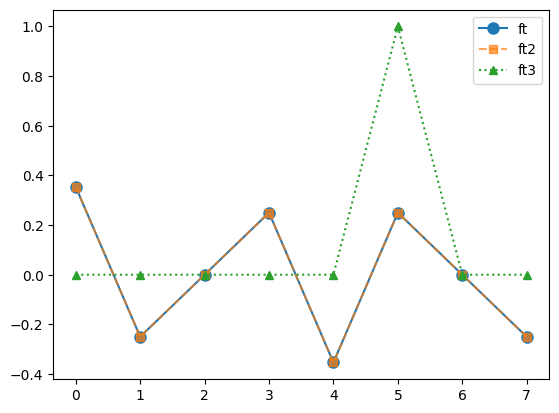

In [40]:
plt.plot(sv_ft.data, 'o-', label='ft', markersize=8)
plt.plot(sv_ft2.data, 's--', label='ft2', markersize=6, alpha=0.7)
plt.plot(sv_ft3.data, '^:', label='ft3')
plt.legend()

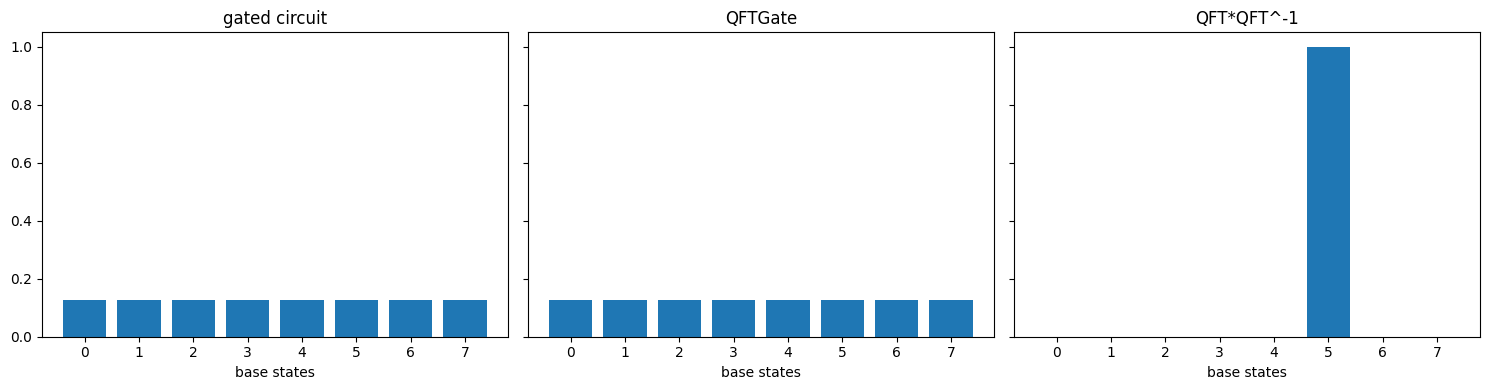

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, data, title in zip(axes, 
    [sv_ft.data, sv_ft2.data, sv_ft3.data], 
    ['gated circuit', 'QFTGate', 'QFT*QFT^-1']):
    ax.bar(range(len(data)), np.abs(data)**2)
    ax.set_title(title)
    ax.set_xlabel('base states')

plt.tight_layout()

> Remarks on QFT: 

QFTGate and the implemented QFT circuit with controlled phase gates give the same superposition of states. 

As expected, QFT and its inverse give back the original state.



---
## 2. Quantum Phase Estimation 

consider $$U = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\theta} \end{pmatrix}$$ where

$$U|\psi \rangle = e^{i\theta}|\psi\rangle$$
$$\psi = 1$$

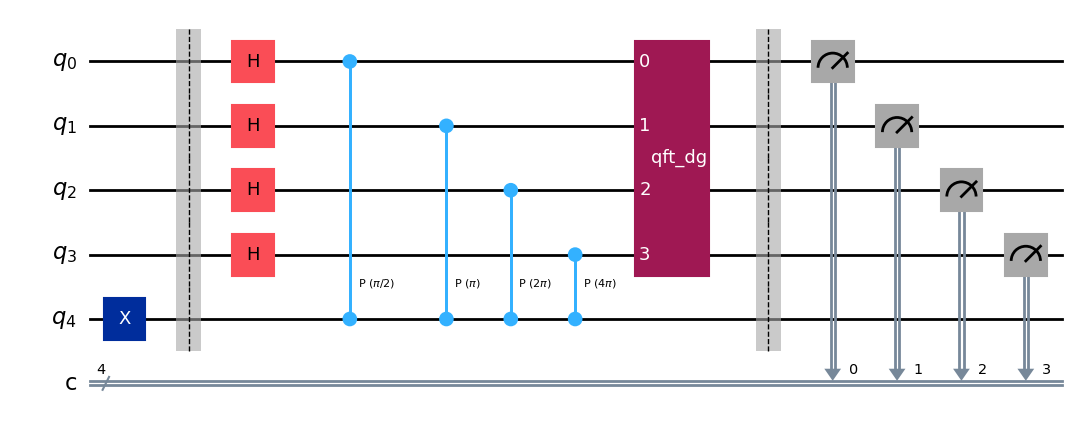

In [ ]:
from math import pi as π
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit.circuit.library import QFTGate

# parameters
n = 4
theta = π / 4

def qpe(n : int, theta : float) -> QuantumCircuit:
    

    q = QuantumRegister(n + 1, 'q')
    c = ClassicalRegister(n, 'c')
    qpe = QuantumCircuit(q, c)

    # initialize to eigenket |1>

    qpe.x(q[n])

    qpe.barrier()


    # hadamards on input registers
    for i in range(n):
        qpe.h(q[i])
        
    # controlled U operator

    for i in range(n):
        qpe.cp(theta * (2 ** i), q[i], q[n])

    qpe.append(QFTGate(n).inverse(), q[:n])

    qpe.barrier()

    qpe.measure(q[:n], c)


    return qpe

qpe1 = qpe(n, theta)

qpe1.draw('mpl')


In [ ]:

from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

In [44]:
backend = AerSimulator()
sampler = AerSampler()

In [45]:
# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
qpe_isa = pm.run(qpe1)

In [46]:
job_sim = sampler.run([qpe_isa], shots=4096)
result_sim = job_sim.result()[0] # Get results for the first circuit

In [47]:
# Print the DataBin to see what's inside
list(result_sim.data.keys())

key = list(result_sim.data.keys())[0]
print(key)


c


In [48]:
counts_sim = result_sim.data[key].get_counts()
print(counts_sim)


{'0100': 4096}


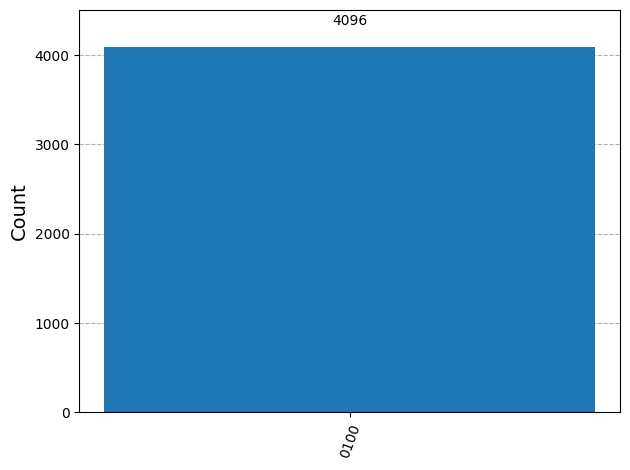

In [49]:
# Plot a histogram of the results
from qiskit.visualization import plot_histogram
plot_histogram(counts_sim)

In [50]:
qpe2 = qpe(n, π / 8)

In [51]:
qpe_isa = pm.run(qpe2)

job_sim = sampler.run([qpe_isa], shots=4096)
result_sim = job_sim.result()[0] # Get results for the first circuit

# Print the DataBin to see what's inside
list(result_sim.data.keys())

key = list(result_sim.data.keys())[0]
print(key)


c


In [52]:
counts_sim = result_sim.data[key].get_counts()
print(counts_sim)


{'0010': 4096}


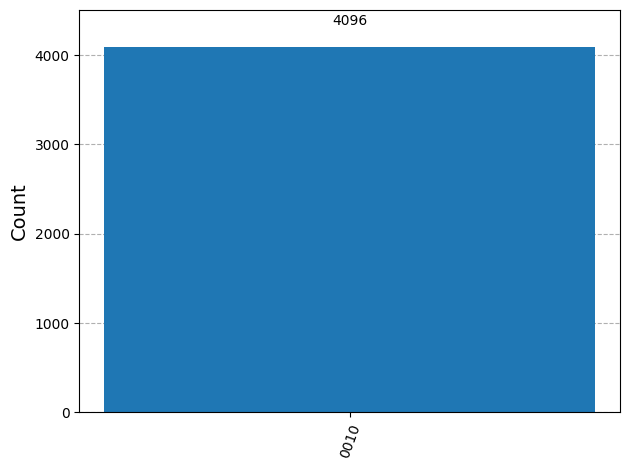

In [53]:
# Plot a histogram of the results
from qiskit.visualization import plot_histogram
plot_histogram(counts_sim)

In [54]:
qpe3 = qpe(n, π / 5)

qpe_isa = pm.run(qpe3)

job_sim = sampler.run([qpe_isa], shots=4096)
result_sim = job_sim.result()[0] # Get results for the first circuit

# Print the DataBin to see what's inside
list(result_sim.data.keys())

key = list(result_sim.data.keys())[0]
print(key)


c


{'0011': 3588, '0010': 111, '0001': 24, '0100': 220, '0110': 21, '0111': 10, '0101': 47, '1110': 13, '1100': 2, '1111': 6, '1101': 6, '1001': 12, '0000': 11, '1010': 6, '1000': 11, '1011': 8}


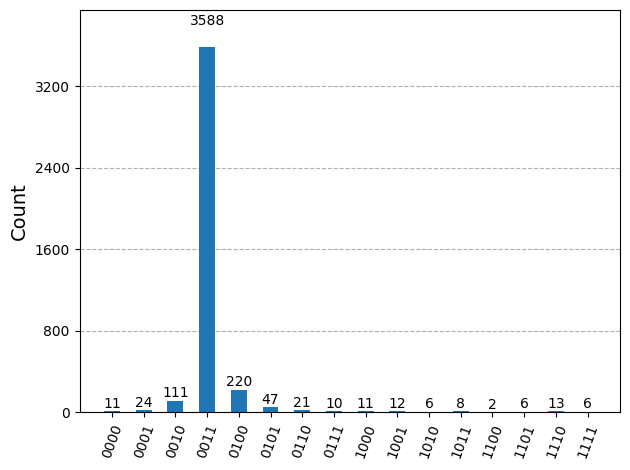

In [55]:
counts_sim = result_sim.data[key].get_counts()
print(counts_sim)
# Plot a histogram of the results
from qiskit.visualization import plot_histogram
plot_histogram(counts_sim)

### Remark: 

π/5 * 2^n is not rational and thus can not be neatly encoded in a bit string. $\frac{\pi}{4} = \frac{\pi}{2^2}$ on the other hand is an integermultiple of $\pi$, as well as $\frac{\pi}{8} = \frac{\pi}{2^3}$ but not $\frac{\pi}{5}$. 